In [1]:
import numpy
print(numpy.__version__)

1.26.4


In [2]:
import sys
project_path = r"D:\DFUC_Project"
if project_path not in sys.path:
    sys.path.append(project_path)

%load_ext autoreload
%autoreload 2

In [3]:
import sys
import torch
from torch.utils.data import DataLoader

project_path = r"D:\DFUC_Project"

if project_path not in sys.path:
    sys.path.append(project_path)

from src.dataset import DFUCDataset, load_annotations
from src.models.custom_cnn import CustomCNNDetector
from src.losses import DetectionLoss

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

train_image_path = r"D:\DFUC_Project\Dataset\DFUC2020\DFUC_Training_Set\images"
annotation_path = r"D:\DFUC_Project\Dataset\DFUC2020\DFUC_Training_Set\groundtruth.csv"

annotations = load_annotations(annotation_path)

dataset = DFUCDataset(
    train_image_path,
    annotations
)

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

print("Device:", device)
print("Dataset size:", len(dataset))
print("Batches:", len(dataloader))

Device: cpu
Dataset size: 2000
Batches: 250


In [5]:
model = CustomCNNDetector().to(device)
criterion = DetectionLoss().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model device:", next(model.parameters()).device)

Model device: cpu


In [6]:
epochs = 400 
training_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        predictions = model(images)

        total_loss, object_loss, box_loss = criterion(
            predictions,
            targets
        )

        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()

    epoch_loss = running_loss / len(dataloader)
    training_losses.append(epoch_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch 1/400 Loss: 0.4977
Epoch 2/400 Loss: 0.4382
Epoch 3/400 Loss: 0.4101
Epoch 4/400 Loss: 0.3967
Epoch 5/400 Loss: 0.3767
Epoch 6/400 Loss: 0.3560
Epoch 7/400 Loss: 0.3330
Epoch 8/400 Loss: 0.3088
Epoch 9/400 Loss: 0.2895
Epoch 10/400 Loss: 0.2730
Epoch 11/400 Loss: 0.2531
Epoch 12/400 Loss: 0.2373
Epoch 13/400 Loss: 0.2248
Epoch 14/400 Loss: 0.2108
Epoch 15/400 Loss: 0.1966
Epoch 16/400 Loss: 0.1876
Epoch 17/400 Loss: 0.1782
Epoch 18/400 Loss: 0.1697
Epoch 19/400 Loss: 0.1632
Epoch 20/400 Loss: 0.1568
Epoch 21/400 Loss: 0.1474
Epoch 22/400 Loss: 0.1410
Epoch 23/400 Loss: 0.1369
Epoch 24/400 Loss: 0.1342
Epoch 25/400 Loss: 0.1289
Epoch 26/400 Loss: 0.1268
Epoch 27/400 Loss: 0.1235
Epoch 28/400 Loss: 0.1159
Epoch 29/400 Loss: 0.1149
Epoch 30/400 Loss: 0.1133
Epoch 31/400 Loss: 0.1090
Epoch 32/400 Loss: 0.1072
Epoch 33/400 Loss: 0.1069
Epoch 34/400 Loss: 0.1052
Epoch 35/400 Loss: 0.1024
Epoch 36/400 Loss: 0.1030
Epoch 37/400 Loss: 0.0982
Epoch 38/400 Loss: 0.0988
Epoch 39/400 Loss: 0.

In [7]:
import os

model_path = r"D:\DFUC_Project\saved_models\custom_cnn_detector.pth"

os.makedirs(os.path.dirname(model_path), exist_ok=True)

torch.save(
    model.state_dict(),
    model_path
)

print("Model saved:", model_path)

Model saved: D:\DFUC_Project\saved_models\custom_cnn_detector.pth


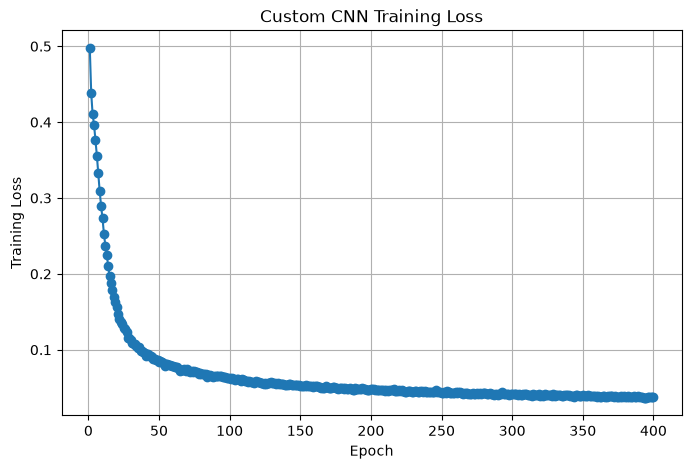

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(training_losses) + 1), training_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Custom CNN Training Loss")
plt.grid()
plt.show()

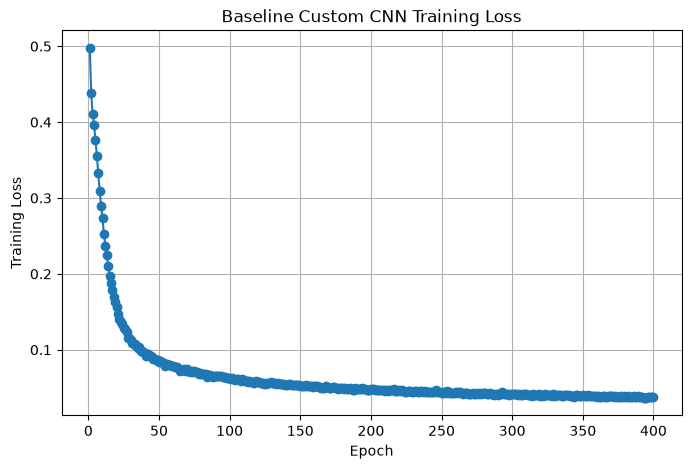

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(training_losses) + 1),
    training_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Baseline Custom CNN Training Loss")
plt.grid()

plt.savefig(
    r"D:\DFUC_Project\results\baseline_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
import os

results_path = r"D:\DFUC_Project\results"

os.makedirs(results_path, exist_ok=True)

print("Results folder ready")

Results folder ready


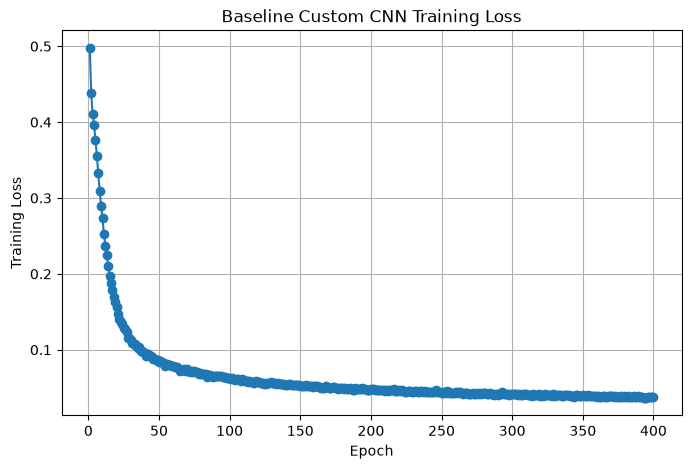

Graph saved


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(training_losses) + 1),
    training_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Baseline Custom CNN Training Loss")
plt.grid()

plt.savefig(
    r"D:\DFUC_Project\results\baseline_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved")